# Final Project Part 2
Name: Branta Mikulecky
Date: April 28, 2026

## Load Datasets and Libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score


pitches_df = pd.read_csv('data/raw/2019_pitches.csv')
games_df = pd.read_csv('data/raw/2019_games.csv')
atbats_df = pd.read_csv('data/raw/2019_atbats.csv')

print("Pitches DataFrame Shape:")
print(pitches_df.head(5))
print(pitches_df.shape)
print(pitches_df.columns)

print("Games DataFrame Shape:")
print(games_df.head(5))
print(games_df.shape)  
print(games_df.columns)

print("At-bats DataFrame Shape:")
print(atbats_df.head(5))
print(atbats_df.shape)
print(atbats_df.columns)

Pitches DataFrame Shape:
     px    pz  start_speed  end_speed    spin_rate     spin_dir  break_angle  \
0  0.00  2.15         88.8       80.7  placeholder  placeholder         22.8   
1  0.34  2.31         89.9       81.8  placeholder  placeholder         22.8   
2 -0.05  2.03         85.7       79.6  placeholder  placeholder          9.6   
3  0.49  0.92         85.4       78.5  placeholder  placeholder         24.0   
4 -0.13  1.11         84.6       77.6  placeholder  placeholder         26.4   

   break_length  break_y     ax  ...  event_num  b_score         ab_id  \
0           4.8     24.0  -8.47  ...          5      0.0  2.019000e+09   
1           3.6     24.0  -7.10  ...          8      0.0  2.019000e+09   
2           6.0     24.0   3.65  ...          9      0.0  2.019000e+09   
3           7.2     24.0 -13.77  ...         10      0.0  2.019000e+09   
4           8.4     24.0 -15.99  ...         11      0.0  2.019000e+09   

   b_count s_count  outs  pitch_num  on_1b  on_2b

## Merge Datasets and Clean Data

In [10]:
df = pd.merge(pitches_df, atbats_df, on='ab_id', how='inner')

print("Merged DataFrame Information:")
print(df.shape)
print(df.dtypes)

print("Missing Values in Each Column Before Cleaning:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(15))

# Drop columns that are unusable because they are completely or mostly missing
df = df.drop(columns=[
    "nasty",
    "spin_rate",
    "spin_dir",
    "type_confidence",
    "zone"
])

# Drop rows missing the key features we actually need
df = df.dropna(subset=[
    "start_speed",
    "end_speed",
    "pitch_type",
    "px",
    "pz",
    "pfx_x",
    "pfx_z",
    "break_angle",
    "break_length"
])

df_clean =df.copy()
print("Missing Values in Each Column After Cleaning:")
missing_after = df.isnull().sum().sort_values(ascending=False)
print(missing_after.head(15))

print("Cleaned DataFrame Information:")
print(df.shape)
print(df.describe())

Merged DataFrame Information:
(728790, 50)
px                 float64
pz                 float64
start_speed        float64
end_speed          float64
spin_rate           object
spin_dir            object
break_angle        float64
break_length       float64
break_y            float64
ax                 float64
ay                 float64
az                 float64
sz_bot             float64
sz_top             float64
type_confidence     object
vx0                float64
vy0                float64
vz0                float64
x                  float64
x0                 float64
y                  float64
y0                 float64
z0                 float64
pfx_x              float64
pfx_z              float64
nasty              float64
zone                object
code                object
type                object
pitch_type          object
event_num            int64
b_score            float64
ab_id              float64
b_count            float64
s_count            float64
outs        

## Visualize Relationships between Features and Target Variable

Outcome of each event type:
target
out    475416
hit    141033
Name: count, dtype: int64


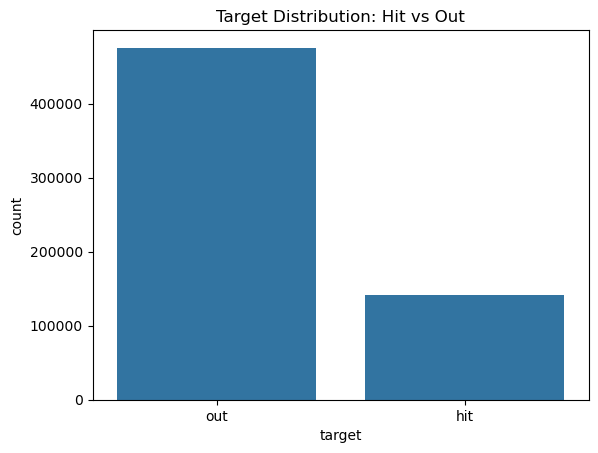

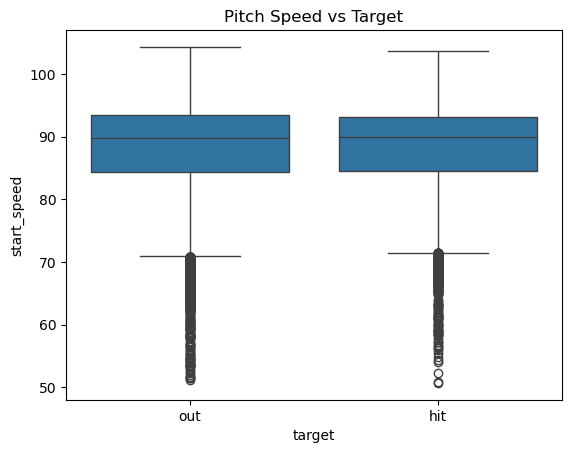

<Figure size 600x800 with 0 Axes>

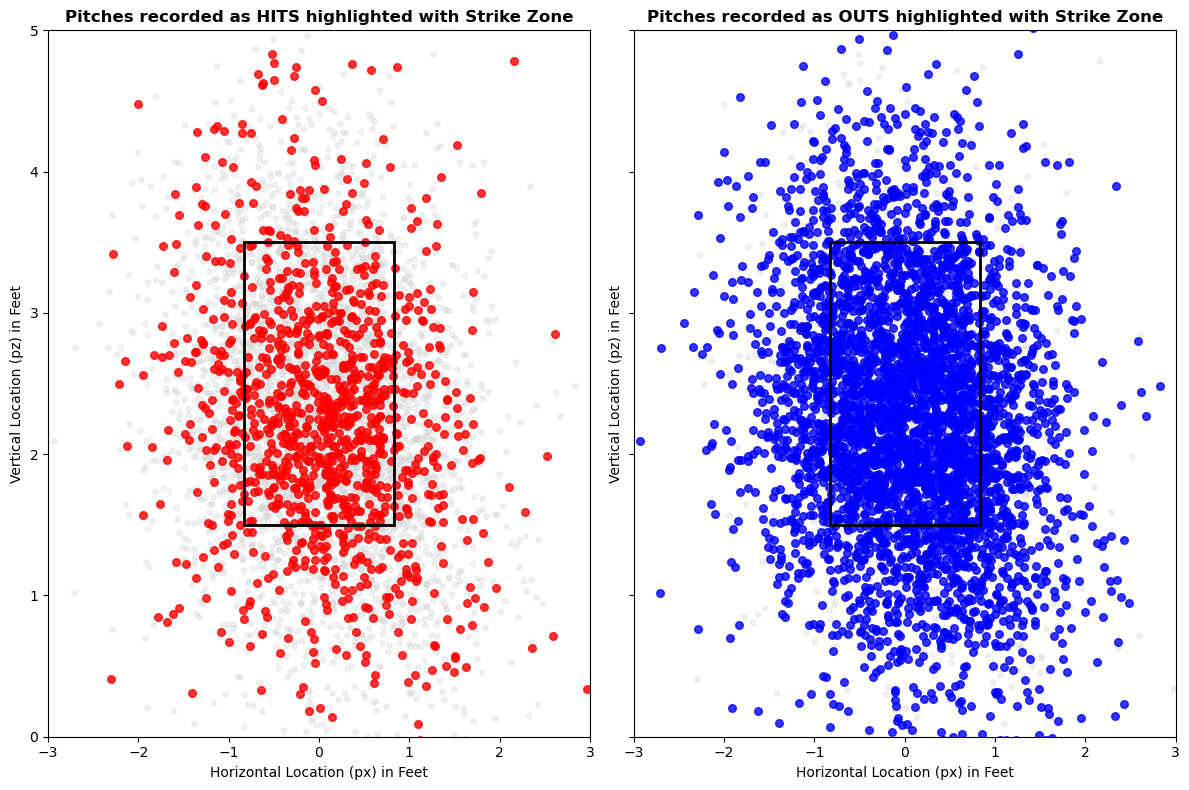

In [11]:

#Set our Target Variable:
valid_events = [
    'Single', 'Double', 'Triple', 'Home Run',
    'Groundout', 'Flyout', 'Lineout', 'Pop Out', 'Strikeout',
    'Forceout', 'Grounded Into DP', 'Double Play',
    'Fielders Choice Out', 'Bunt Groundout', 'Bunt Pop Out', 
    'Bunt Lineout', 'Strikeout Double Play'
]

df_model = df_clean[df_clean['event'].isin(valid_events)].copy()

df_model['target'] = df_model['event'].apply(
    lambda x: 'hit' if x in ['Single', 'Double', 'Triple', 'Home Run'] else 'out'
)

print("Outcome of each event type:")
print(df_model['target'].value_counts())

#Visualizations:
sns.countplot(x='target', data=df_model)
plt.title("Target Distribution: Hit vs Out")
plt.show()

sns.boxplot(x='target', y='start_speed', data=df_model)
plt.title("Pitch Speed vs Target")
plt.show()

plt.figure(figsize=(6, 8))

# Scatter plot
sample_df = df_model.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

# --- Plot 1: Highlight HITS ---
axes[0].scatter(
    sample_df[sample_df['target'] == 'out']['px'],
    sample_df[sample_df['target'] == 'out']['pz'],
    color='lightgray',
    alpha=0.3,
    s=15,
    label='out'
)

axes[0].scatter(
    sample_df[sample_df['target'] == 'hit']['px'],
    sample_df[sample_df['target'] == 'hit']['pz'],
    color='red',
    alpha=0.8,
    s=30,
    label='hit'
)

axes[0].set_title("Pitches recorded as HITS highlighted with Strike Zone", fontsize=12, fontweight='bold')

# --- Plot 2: Highlight OUTS ---
axes[1].scatter(
    sample_df[sample_df['target'] == 'hit']['px'],
    sample_df[sample_df['target'] == 'hit']['pz'],
    color='lightgray',
    alpha=0.3,
    s=15,
    label='hit'
)

axes[1].scatter(
    sample_df[sample_df['target'] == 'out']['px'],
    sample_df[sample_df['target'] == 'out']['pz'],
    color='blue',
    alpha=0.8,
    s=30,
    label='out'
)

axes[1].set_title("Pitches recorded as OUTS highlighted with Strike Zone", fontsize=12, fontweight='bold')

# --- Add strike zone to BOTH plots ---
for ax in axes:
    strike_zone = plt.Rectangle(
        (-0.83, 1.5),
        1.66,
        2.0,
        fill=False,
        color='black',
        linewidth=2
    )
    ax.add_patch(strike_zone)
    ax.set_xlim(-3, 3)
    ax.set_ylim(0, 5)
    ax.set_xlabel("Horizontal Location (px) in Feet")
    ax.set_ylabel("Vertical Location (pz) in Feet")

plt.tight_layout()
plt.show()

## Key Data Characteristics
After reviewing and cleaning the data, I found out that there are 475,416 pitches that recorded outs and 141,033 pitches that recorded hits. That means there is an imbalance in our out-to-hit ratio, which may cause our model to predict outs more inaccurately. Based on our visualizations, we can see that speed doesn't show too much relevance in our box chart. However, in our scatterplot with the strike zone, we can see hits are more likely to occur in the central part of the strike zone, and pitches outside of the strike zone are harder to hit, implying location is important. Overall, we will need to utilize more features to help our model's accuracy and credibility.

## Engineered Features

In [12]:
#Engineered Feature #1
df_model['total_movement'] = np.sqrt(df_model['pfx_x']**2 + df_model['pfx_z']**2) * 12

### Total Movement Feature
This feature calculates the total movement of a pitch. It does this by taking the horizontal movement (pfx_x) and the vertical movement (pfx_z), and using the Pythagorean theorem to calculate the total movement (hypotenuse). So the equation looks like this: √(pfx_x² + pfx_z² ) x 12 (converts feet to inches)= Total Pitch movement. This feature will help the model understand how the amount of pitch movement affects the outcome. Theoretically, if a pitch moves more, it is harder to hit.

In [13]:
#Engineered Feature #2
df_model['speed_movement_score'] = df_model['start_speed'] * df_model['total_movement']

### Speed Movement Score Feature
This feature assigns each pitch a score based on its velocity and how much it moves. It builds off of our previous feature and multiplies start_speed by total_movement. The reason we use start_speed instead of end_speed is because MLB records velocity at its top speed, which is usually the speed out of the hand. This will help our model because pitches that are both fast and have more movement are harder to hit. So, theoretically, the higher the speed movement score, the lower the chances are that a batter will get a hit.

In [14]:
#Engineered Feature #3
df_model['in_zone'] = (
    (df_model['px'].between(-0.83, 0.83)) &
    (df_model['pz'].between(1.5, 3.5))
).astype(int)

### Strike or Ball Feature
This feature calculates if a pitch is in the strike zone. It does this by creating an approximate strike zone based on MLB dimensions. If the pitch location is in that zone, it counts it as a strike (1). Otherwise, it counts it as a ball (0). This will help the model understand what pitch locations correlate to hits and outs. In baseball, the more the ball is outside of the strike zone, or “swing zone,” the harder it is to hit (which is backed up by the scatterplot from earlier).

In [15]:
# Engineered Feature #4
df_model['runners_on'] = (
    (df_model['on_1b'].notnull()) |
    (df_model['on_2b'].notnull()) |
    (df_model['on_3b'].notnull())
).astype(int)

### Runners On Feature
To give our random forest more context when predicting pitch outcomes, it’s important to include batter situation context. The runners_on feature tracks whether there are runners on base, which can influence how both the hitter and pitcher approach the at-bat. In these situations, hitters may be more aggressive to drive in runs, while pitchers may adjust their pitch selection. By including this feature, the model can better understand how pitch effectiveness changes based on the game situation.

In [16]:
# Engineered Feature #5
df_model['runners_in_scoring_position'] = (
    (df_model['on_2b'].notnull()) |
    (df_model['on_3b'].notnull())
).astype(int)

### Runners in Scoring Position Feature
This feature tracks pitches thrown when there is a runner on second or third base. These situations are important because there is a direct threat of scoring, which often causes both the pitcher and hitter to adjust their approach. Pitch selection becomes more critical, as one mistake can lead to runs being scored. By including this feature, the model can better evaluate pitch effectiveness in high-impact situations and make more informed predictions.

In [17]:
# Engineered Feature #6
df_model['high_pressure'] = (
    (df_model['outs'] == 2) &
    (df_model['runners_in_scoring_position'] == 1)
).astype(int)

### High Pressure Feature
This feature tracks pitches thrown in high-pressure situations, defined as having runners in scoring position with two outs. In these moments, the batter has a strong opportunity to drive in runs, while the pitcher is one out away from ending the inning. Because of this, both players tend to adjust their approach, making these situations especially important. By including this feature, the model can better understand how pitch effectiveness changes during crucial game moments.

## Data Modeling Preperation

In [23]:
# First, let's create a list of features to use in our model
features = [
    'start_speed',
    'end_speed',
    'px',
    'pz',
    'pfx_x',
    'pfx_z',
    'break_angle',
    'break_length',
    'outs',
    'total_movement',         
    'speed_movement_score',
    'in_zone',
    'runners_on',
    'runners_in_scoring_position',
    'high_pressure'
]

X = df_model[features]
y = df_model['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Already Handled missing values earlier
# Scale the data for neural networks

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA Application:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

I selected features like pitch speed, pitch location, pitch break, and our engineered features for the train/test split. I stratified the split because our data is imbalanced. This ensures that the ratio of hits to outs stays consistent so the model can develop properly. I then scaled the training and testing data because we will need the data to be on the same scale when building our neural network model.

### Fixing Class Imbalance

In [19]:
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{'hit': np.float64(2.1854847286972863), 'out': np.float64(0.6483252833700993)}


This makes hits more important weighing them at 2.18. Whereas outs are now less important at 0.65. This penalizes our model for missing hits, and forces the model to learn hitting patterns.

## First Model: Random Forest Classifier (Simple Model)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest Parameters:
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 150}

Grid Search Training Time: 843.55 seconds
Optimized Random Forest Results
-------------------------------
Accuracy: 0.5940
Training Time: 843.55 seconds

Classification Report:
              precision    recall  f1-score   support

         hit       0.26      0.42      0.32     28207
         out       0.79      0.65      0.71     95083

    accuracy                           0.59    123290
   macro avg       0.52      0.53      0.52    123290
weighted avg       0.67      0.59      0.62    123290



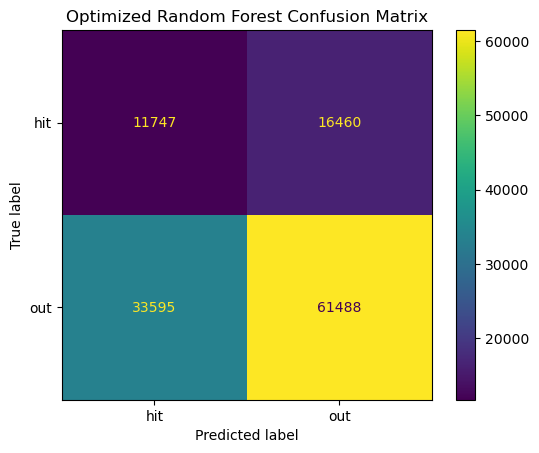

In [20]:
# Initialize base Random Forest
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight=class_weight_dict
)

# Hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

# Grid search
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Train optimized RF
start_time = time.time()
rf_grid.fit(X_train, y_train)
rf_training_time = time.time() - start_time

# Best model
best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print()
print(f"Grid Search Training Time: {rf_training_time:.2f} seconds")

# Predict with optimized RF
rf_predictions = best_rf_model.predict(X_test)

# Evaluate optimized RF
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Optimized Random Forest Results")
print("-------------------------------")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Training Time: {rf_training_time:.2f} seconds")
print()
print("Classification Report:")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_predictions, labels=best_rf_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_rf_model.classes_
)

disp.plot()
plt.title("Optimized Random Forest Confusion Matrix")
plt.show()

## Second Model: Principle Component Analysis (PCA) 

PCA + Random Forest Results
----------------------------
Accuracy: 0.5945
Training Time: 374.73 seconds

Classification Report:
              precision    recall  f1-score   support

         hit       0.26      0.41      0.32     28207
         out       0.79      0.65      0.71     95083

    accuracy                           0.59    123290
   macro avg       0.52      0.53      0.51    123290
weighted avg       0.67      0.59      0.62    123290



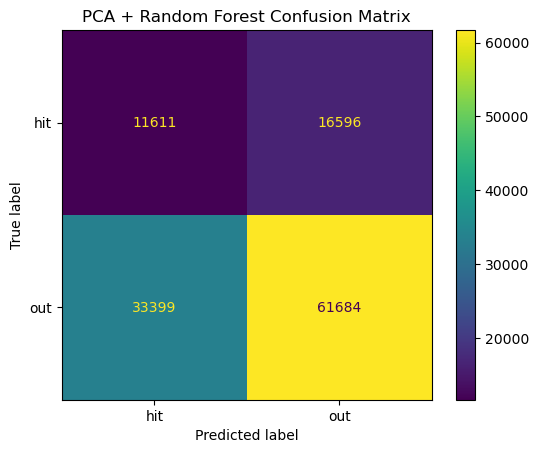

In [26]:
# Train PCA Random Forest
start_time = time.time()

rf_pca = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    class_weight=class_weight_dict
)

rf_pca.fit(X_train_pca, y_train)
pca_training_time = time.time() - start_time

# Predict
pca_predictions = rf_pca.predict(X_test_pca)

# Accuracy
pca_accuracy = accuracy_score(y_test, pca_predictions)

print("PCA + Random Forest Results")
print("----------------------------")
print(f"Accuracy: {pca_accuracy:.4f}")
print(f"Training Time: {pca_training_time:.2f} seconds")
print()
print("Classification Report:")
print(classification_report(y_test, pca_predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, pca_predictions, labels=rf_pca.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_pca.classes_
)

disp.plot()
plt.title("PCA + Random Forest Confusion Matrix")
plt.show()

## Model Optimization Strategy
#### To optimize my models, I focused on improving feature engineering by adding features that better capture pitch effectiveness by adding game situation context. I also addressed class imbalance by applying class weighting, which made hits more important than outs and allowed the model to learn from both classes more effectively. While attempting to optimize a neural network, TensorFlow caused my kernal to continuely crash. Neural networks are generally less effective for structured tabular data like this anyways. So, I selected PCA with a Random Forest model as my second approach. PCA reduces the feature space into a smaller set of principal components, helping remove noise while preserving the most important variance in the data.

## Comprehensive Performance Visualizations

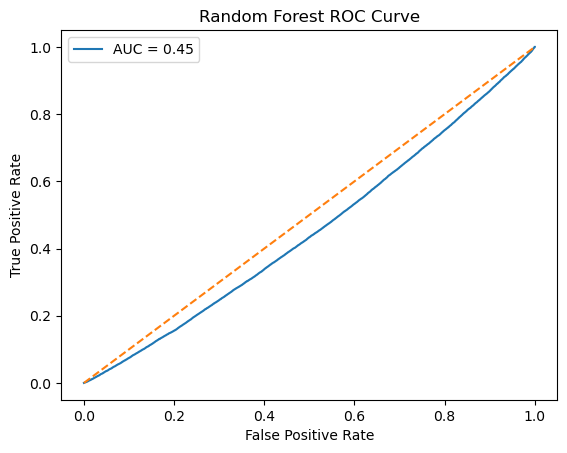

In [27]:
# ROC Curve Visualization
from sklearn.metrics import roc_curve, auc
# Get probabilities for positive class ('hit')
y_probs = best_rf_model.predict_proba(X_test)[:, 1]

# Convert labels if needed
y_test_binary = (y_test == 'hit').astype(int)

fpr, tpr, _ = roc_curve(y_test_binary, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

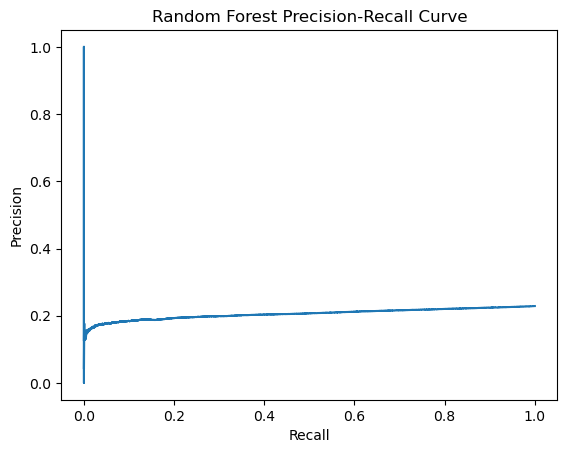

In [28]:
# Precision-Recall Curve Visualization
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test_binary, y_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.show()

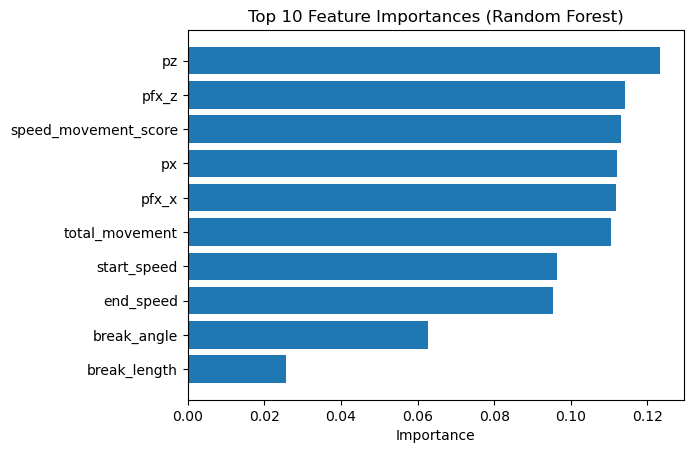

In [29]:
# Feature Importance Visualization
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot top 10 features
plt.figure()
plt.barh(feat_imp['feature'][:10][::-1], feat_imp['importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

## Model Performance Comparison

In [31]:


# Create reports
rf_report = classification_report(y_test, rf_predictions, output_dict=True)
pca_report = classification_report(y_test, pca_predictions, output_dict=True)

# Pull metrics
rf_hit_recall = rf_report['hit']['recall']
rf_out_recall = rf_report['out']['recall']
rf_macro_f1 = rf_report['macro avg']['f1-score']

pca_hit_recall = pca_report['hit']['recall']
pca_out_recall = pca_report['out']['recall']
pca_macro_f1 = pca_report['macro avg']['f1-score']

# Comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Optimized Random Forest', 'PCA + Random Forest'],
    'Key Hyperparameters': [
        'n_estimators=150, max_depth=15, min_samples_split=5, class_weight=balanced',
        'PCA + n_estimators=150, max_depth=15, min_samples_split=5, class_weight=balanced'
    ],
    'Accuracy': [rf_accuracy, pca_accuracy],
    'Hit Recall': [rf_hit_recall, pca_hit_recall],
    'Out Recall': [rf_out_recall, pca_out_recall],
    'Macro F1': [rf_macro_f1, pca_macro_f1],
    'Training Time (s)': [rf_training_time, pca_training_time],
    'Interpretability': ['Medium/High', 'Medium/Low'],
    'Notes': [
        'Uses original features and provides feature importance, but trains slower',
        'Similar performance with faster training, but PCA components are harder to interpret'
    ]
})

comparison_df

print("\n" + "="*110)
print("MODEL COMPARISON")
print("="*110)

print(f"{'Model':<30}{'Architecture':<35}{'Accuracy':<12}{'Hit Recall':<12}{'Out Recall':<12}{'Macro F1':<12}{'Train Time'}")

print(f"{'Optimized Random Forest':<30}"
      f"{'150 Trees, Depth=15':<35}"
      f"{rf_accuracy:<12.4f}"
      f"{rf_hit_recall:<12.2f}"
      f"{rf_out_recall:<12.2f}"
      f"{rf_macro_f1:<12.2f}"
      f"{rf_training_time:.2f}")

print(f"{'PCA + Random Forest':<30}"
      f"{'PCA + 150 Trees, Depth=15':<35}"
      f"{pca_accuracy:<12.4f}"
      f"{pca_hit_recall:<12.2f}"
      f"{pca_out_recall:<12.2f}"
      f"{pca_macro_f1:<12.2f}"
      f"{pca_training_time:.2f}")

print("="*110)


MODEL COMPARISON
Model                         Architecture                       Accuracy    Hit Recall  Out Recall  Macro F1    Train Time
Optimized Random Forest       150 Trees, Depth=15                0.5940      0.42        0.65        0.52        843.55
PCA + Random Forest           PCA + 150 Trees, Depth=15          0.5945      0.41        0.65        0.51        374.73


### Comparison Table Analysis
Based on our results, PCA + Random Forest performed the best. This model scored an accuracy of 59% with a training time of 375 seconds. This is barely better than our optimized random forest classifier, as optimized Random Forest model was 0.45% worse in accuracy. 

However, the biggest trade off was how long it took for each model to train compared to interpretability. The optimized random forest model took 844 seconds to train (14 minutes), where PCA + RF took 375 seconds (~6-7 minutes). 

The optimized random forest was easily interpreted because of how it trained on original features. Whereas, PCA + RF trained on transformed features, speeding up the process, but decreasing interpretability. The model I would choose based on these results is PCA + RF, because it achieved better accuracy in half the time. 

## Ethical Analysis & Responsible Deployment


One major source of bias in this model comes from the use of historical data from the 2019 MLB season. Over the past several years, baseball has evolved significantly due to advancements in biomechanics, analytics, and player development. As a result, the patterns learned by the model may not fully reflect current pitching strategies or hitter behavior. This introduces historical bias, where the model reinforces outdated trends. Additionally, representation bias exists because the dataset only includes MLB-level players, meaning the model may not generalize well to other levels of competition.

If the model makes incorrect predictions, coaches and players would be the most affected. For example, if the model predicts that a pitch is likely to result in an out when it actually leads to a hit, a pitcher may rely on a poor pitch selection in a critical moment. False positives (predicting an out when the result is a hit) are particularly harmful because they can create overconfidence in certain pitches. Given that the model performs only slightly better than random guessing, relying on it as a primary decision-making tool could negatively impact team performance. However, pitch outcomes are inherently difficult to predict due to the many variables involved, so the model should be viewed as a supporting tool rather than a definitive answer.

To mitigate these risks, several steps should be taken before deployment. First, the model should be retrained using more recent data to better reflect current gameplay trends. Second, the data can be segmented by pitcher characteristics such as handedness and arm slot to create more specialized and accurate models. Third, the model should be used alongside human expertise rather than as a fully automated system. Finally, ongoing monitoring and retraining should be implemented to ensure the model remains accurate and relevant over time. These steps help reduce bias and promote responsible use of the model.

## Business Recommendations & Deployment Considerations
Based on the feature importance results, pitch location (px, pz), pitch movement (pfx_x, pfx_z), and the interaction between speed and movement are the most influential factors in determining pitch outcomes. Coaches should prioritize consistent pitch location—especially targeting the edges of the strike zone—and focus on developing movement that induces weak contact. In addition, these insights can inform pitch sequencing strategies, helping pitchers decide which pitches to throw in specific counts or situations. This becomes especially important in high-leverage scenarios such as runners in scoring position or two-out situations, where execution can directly impact game outcomes.

For deployment, this model should be used as a decision-support tool rather than a fully automated system. The model provides probabilities that can help guide pitch selection, but it should not replace human judgment. Coaches should continue to rely on scouting reports, pitcher strengths, and situational awareness when making decisions. The model’s outputs are best used to supplement these factors, not override them.

There are several limitations stakeholders should consider. First, the model was trained on 2019 data, which may not reflect current trends due to advancements in player development and analytics. Second, the model performs only slightly better than random guessing and struggles to accurately predict hits, meaning it should not be relied on as a primary decision-making tool. Finally, baseball outcomes are influenced by many factors not included in the dataset, such as batter skill, timing, defensive positioning, and environmental conditions. Because of these limitations, the model should be used cautiously and in combination with domain expertise.